# package_lab

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors
import os

import package_lab 
import package_DBR

from importlib import reload
package_lab = reload(package_lab)

from package_DBR import myRound, SelectPath_RT, Delay_RT, Bode, Process
from package_lab import LL_RT, IMCTuning, Margin, PID_RT, PID

# LL_RT()

In [2]:
help(LL_RT)

Help on function LL_RT in module package_lab:

LL_RT(MV, Kp, Tlag, Tlead, Ts, PV, PVInit=0, method='EBD')
    The function "FO_RT" needs to be included in a "for or while loop".

    :MV: input vector
    :Kp: process gain
    :T: lag time constant [s]
    :Ts: sampling period [s]
    :PV: output vector
    :PVInit: (optional: default value is 0)
    :method: discretisation method (optional: default value is 'EBD')
        EBD: Euler Backward difference
        EFD: Euler Forward difference
        TRAP: Trapezoïdal method

    The function "FO_RT" appends a value to the output vector "PV".
    The appended value is obtained from a recurrent equation that depends on the discretisation method.



(0.0, 100.0)

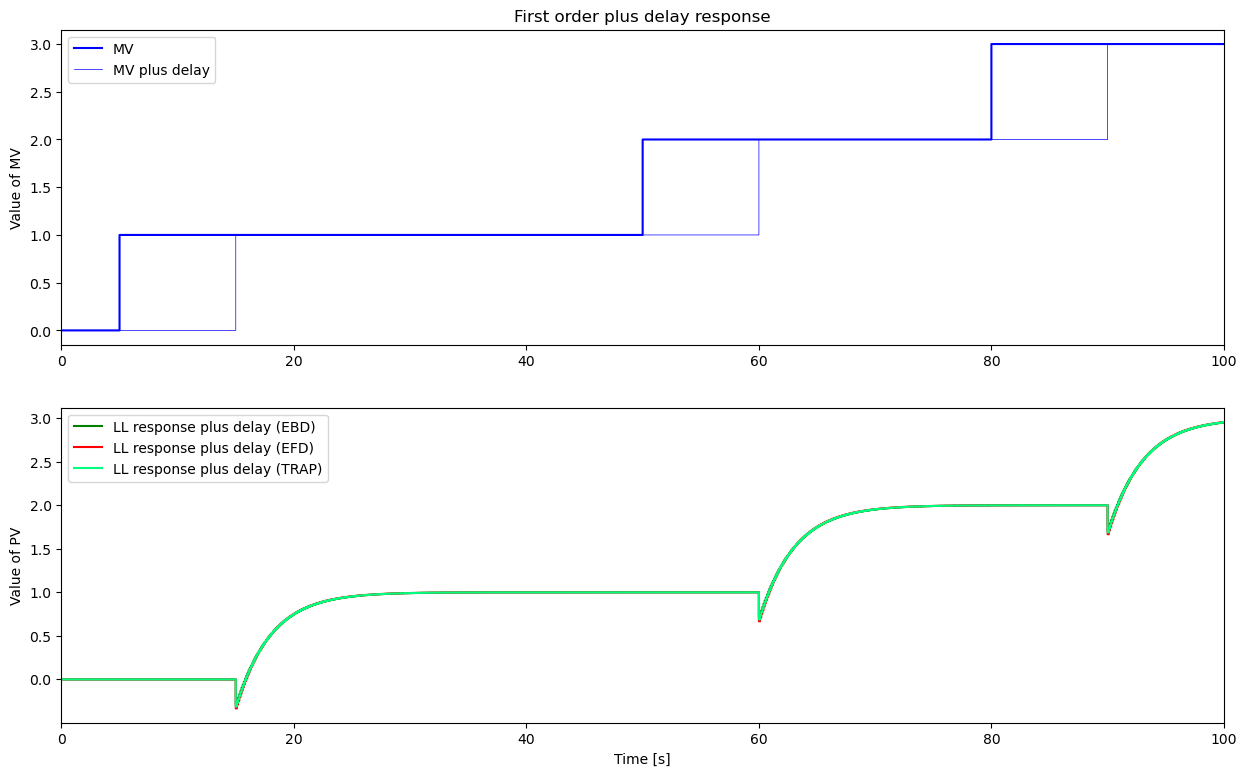

In [3]:
TSim = 100
Ts = 0.1
N = int(TSim/Ts) + 1

# Path for MV
MVPath = {0: 0, 5: 1, 50: 2, 80: 3, TSim: 3}

t = []
MV = []
MVDelay = []
PV_EBD = []
PV_EFD = []
PV_TRAP = []

# Parameters
Kp = 1
Tlead = -1
Tlag = 3
theta = 10

for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(MVPath,t,MV)
    Delay_RT(MV,theta,Ts,MVDelay)
    LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_EBD,0,'EBD')
    LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_EFD,0,'EFD')
    LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_TRAP,0,'TRAP')
    
plt.figure(figsize = (15,9))

plt.subplot(2,1,1)
plt.step(t,MV,'b-',label='MV',where='post')
plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of MV')
plt.title('First order plus delay response')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(2,1,2)
plt.step(t,PV_EBD,'g-',label='LL response plus delay (EBD)',where='post')
plt.step(t,PV_EFD,'r',label='LL response plus delay (EFD)',where='post')
plt.step(t,PV_TRAP,'springgreen',label='LL response plus delay (TRAP)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])    

# PID

## PID avec methode EBD

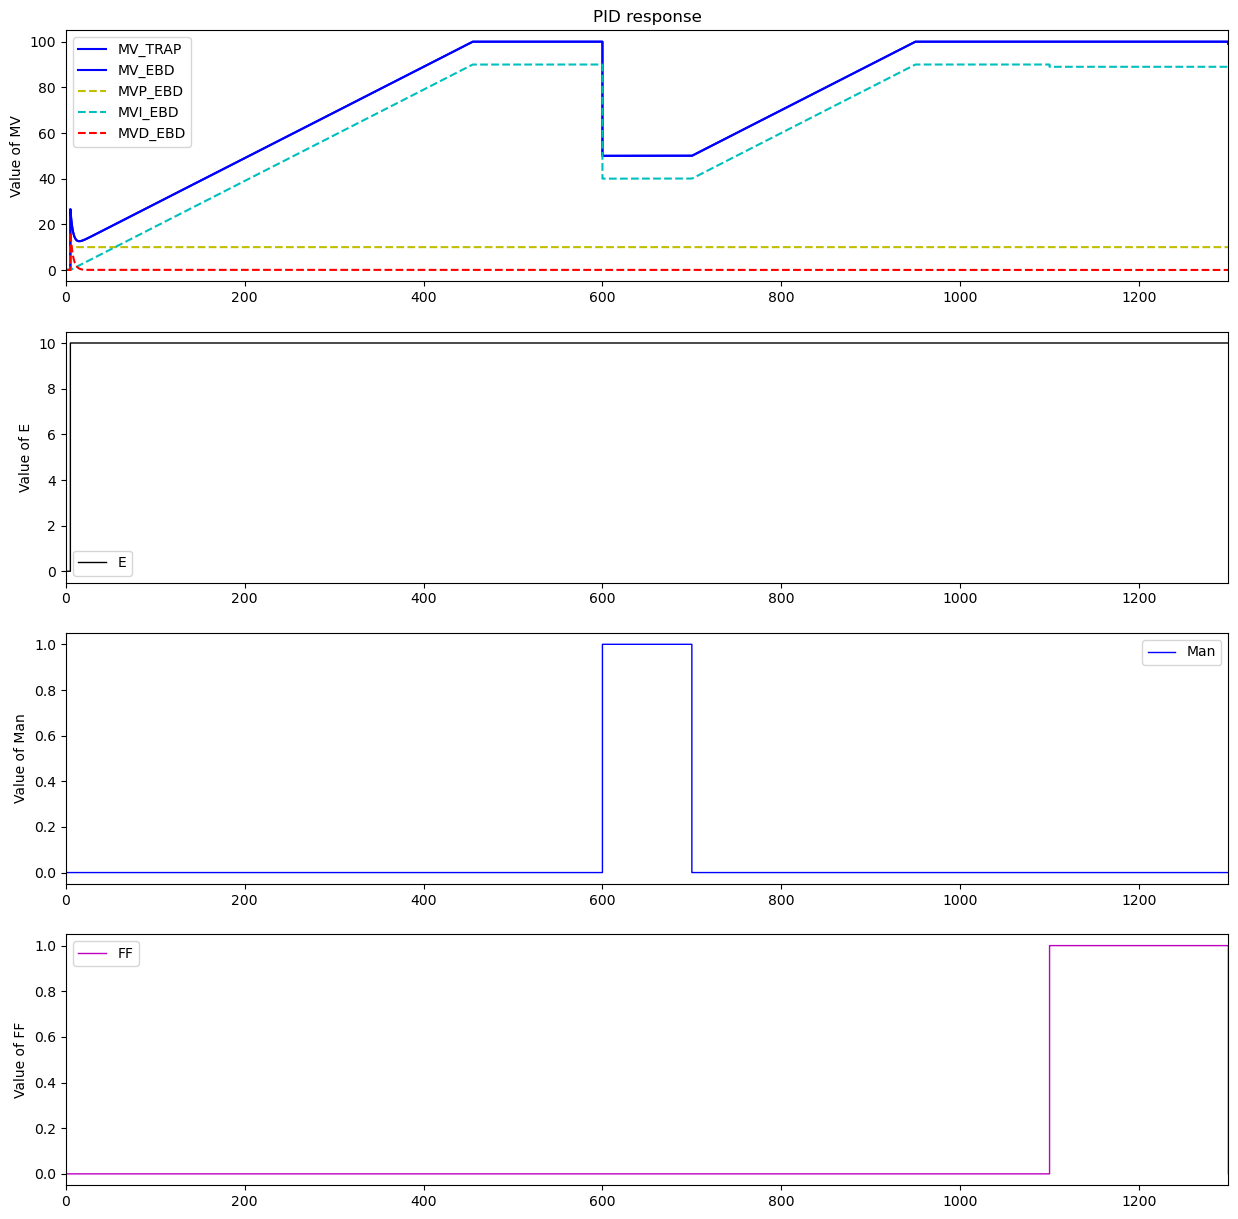

In [4]:
t = []

TSim = 1300


SP = []
MV = []
PV = []
DV =[]
Man = []
MVMan = []
MVFF = []
MVManPath = {0:50, TSim:50}
SPPath = {0: 50, 5: 60, TSim : 60}
PVPath = {0:50, 5:50, TSim:50}


ManPath = {0: False, 600: True, 700:False, TSim : False}
MVFFPath = {0:0, 1100: True, TSim : False}

Kc = 1
Ti = 50
Td = 5
alpha = 0.6
Ts = 0.01
N = int(TSim/Ts) + 1
MVmin = 0 
MVmax = 100

MVP = []
MVI = []
MVD = [] 
E  = []
MVP2 = []
MVI2 = []
MVD2 = [] 


for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(SPPath, t,SP)
    SelectPath_RT(PVPath, t,PV)
    SelectPath_RT(ManPath, t,Man)
    SelectPath_RT(MVManPath, t,MVMan)
    SelectPath_RT(MVFFPath, t, MVFF)

    PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVmin, MVmax, MV, MVP, MVI, MVD, E,False,0,"EBD-EBD")

plt.figure(figsize = (15,15))
plt.subplot(4,1,1)
plt.step(t,MV,'b-',label='MV_TRAP',where='post')
#plt.step(t,MVP,'y-',label='MVP_TRAP',where='post')
#plt.step(t,MVI,'g-',label='MVI_TRAP',where='post')
#plt.step(t,MVD,'r-',label='MVD_TRAP',where='post')
#plt.step(t,E ,'-m',linewidth=0.5,label='E_TRAP',where='post')

plt.step(t,MV,'b-',label='MV_EBD',where='post')
plt.step(t,MVP,'--y',label='MVP_EBD',where='post')
plt.step(t,MVI,'--c',label='MVI_EBD',where='post')
plt.step(t,MVD,'--r',label='MVD_EBD',where='post')
#plt.step(t,E2 ,'-m',linewidth=0.5,label='E_EBD',where='post')
#plt.step(t,SP ,'c--',linewidth=0.5,label='E',where='post')

plt.ylabel('Value of MV')
plt.title('PID response')
plt.legend(loc='best')
plt.xlim([0, TSim])

# E
plt.subplot(4,1,2)
plt.step(t,E ,'k-',linewidth=1,label='E',where='post')
plt.ylabel('Value of E')
plt.legend(loc='best')
plt.xlim([0, TSim])

# Man
plt.subplot(4,1,3)
plt.step(t,Man,'b-',linewidth=1,label='Man',where='post')
plt.ylabel('Value of Man')
plt.legend(loc='best')
plt.xlim([0, TSim])

# FF
plt.subplot(4,1,4)
plt.step(t,MVFF,'m-',linewidth=1,label='FF',where='post')
plt.ylabel('Value of FF')
plt.legend(loc='best')
plt.xlim([0, TSim])

nameFile = 'Plots/Step_Response_PID_EBD_alpha_influence'

if not os.path.exists('Plots'):
    os.makedirs('Plots')
    
#plt.savefig(nameFile + '.png',transparent=True)
#plt.savefig(nameFile + '.pdf',transparent=True)  


# IMC TUNING

In [5]:
# Parameters for input-output dynamic
Kp = 0.375
T1p = 128.82 
T2p = 73.34 
thetap = 9.30 

# Parameters PID controller
gamma = 0.9                                # A faire : Discuter variation de gamma
Kc, Ti, Td = IMCTuning(Kp,T1p,T2p,thetap,gamma, process='SOPDT')

print("Kc = ",Kc)
print("Ti = ",Ti)
print("Td = ",Td)

Kc =  4.304550801939773
Ti =  202.16
Td =  46.73357142857142


# Margin

Gain margin : 21.96807057523538 dB at the ultimate frequency : 0.2557648060237572 rad/s
Phase margin :  96.17947340480696 ° at the crossover frequency : 0.009702835977454843 rad/s


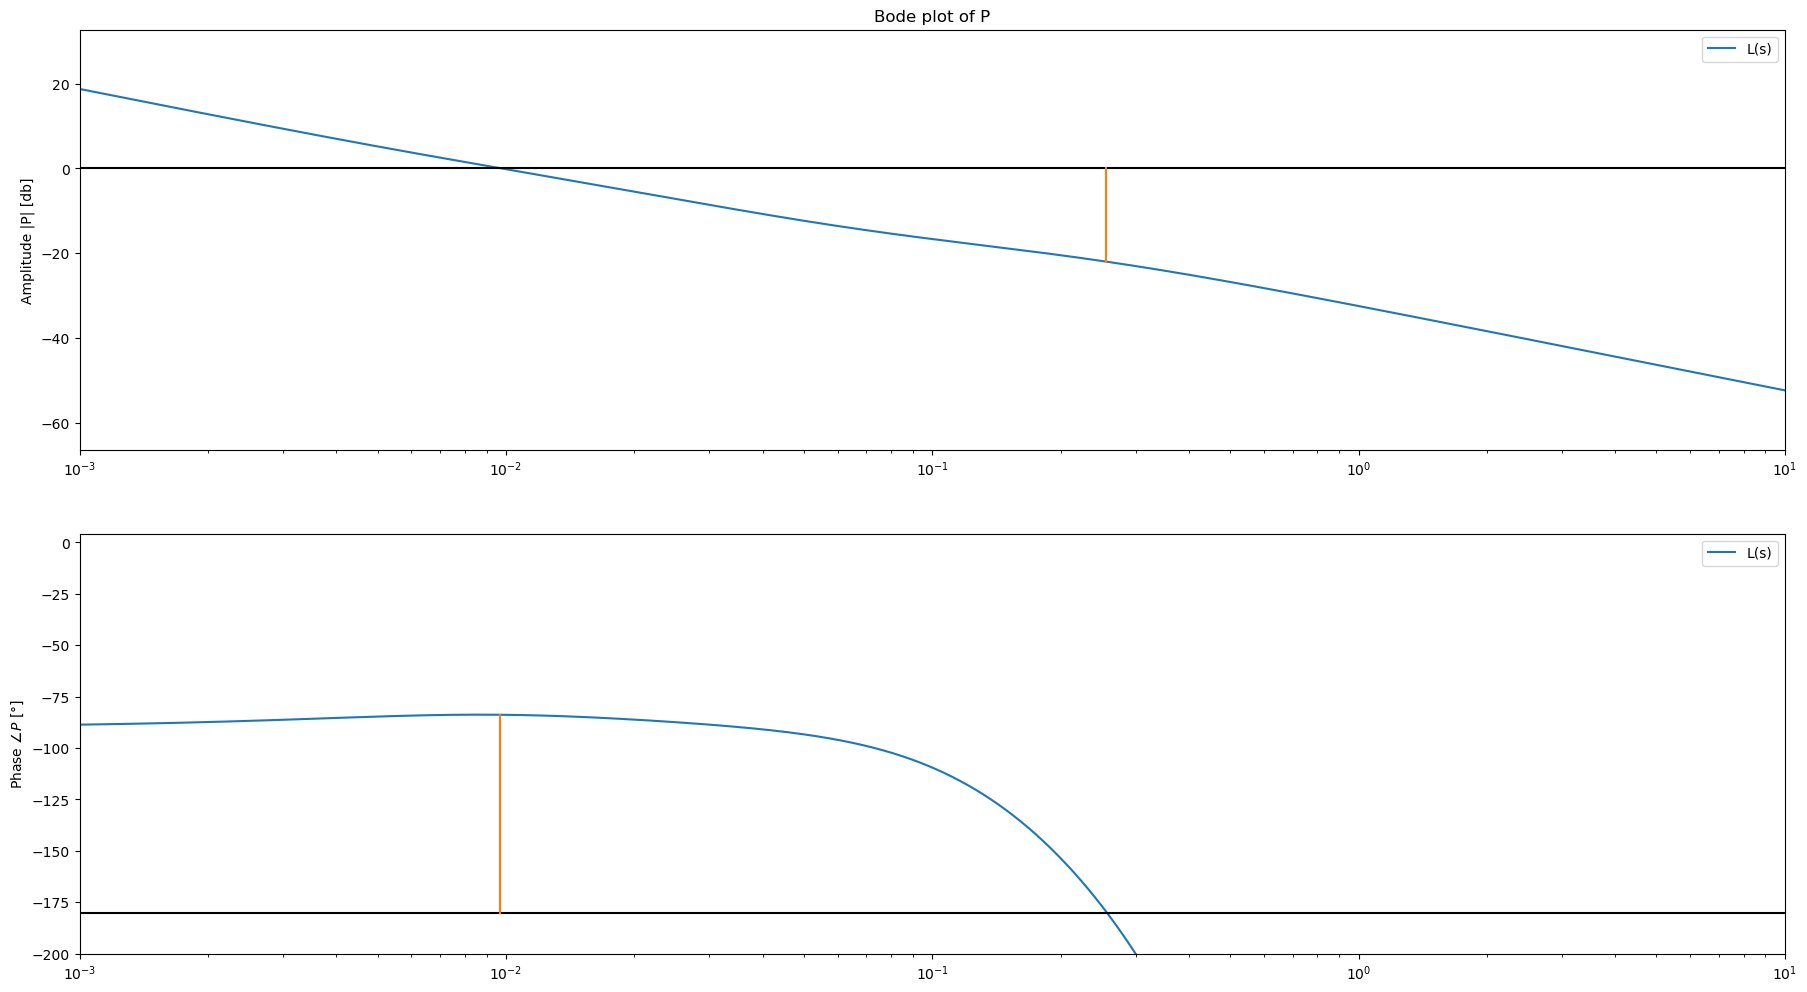

In [6]:
P = Process({})

Kp = 0.42
Tlag1 = 93.5
Tlag2 = 0
theta = 7.4
T1p = 119 # Tg
T2p = 6 # Tu

P.parameters['Kp'] = Kp
P.parameters['Tlag1'] = Tlag1
P.parameters['Tlag2'] = Tlag2
P.parameters['theta'] = theta

Kc, Ti, Td = IMCTuning(Kp,T1p,T2p,thetap,gamma, 'SOPDT')
alpha = 0.9

C = PID({})
C.parameters['Kc'] = Kc
C.parameters['Ti'] = Ti
C.parameters['Td']= Td
C.parameters['Tfd'] = alpha *Td # temps dérivation après filtrage


omega = np.logspace(-3,1,10000)

Ps = Bode(P,omega,Show=False)

Margin(Ps,C,omega)